<a href="https://colab.research.google.com/github/samreenfathima18/Guvi-Final-project/blob/main/LightGBM_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install LightGBM**

In [ ]:
!pip install -q lightgbm

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
import os

from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Data**

In [ ]:
DATA_PATH="/content/drive/MyDrive/Enterprise_Retail_Intelligence/prepared_data/"
RESULTS_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/results/"

X_train=pd.read_parquet(DATA_PATH+"X_train.parquet")
X_valid=pd.read_parquet(DATA_PATH+"X_valid.parquet")
X_test=pd.read_parquet(DATA_PATH+"X_test.parquet")

y_train=pd.read_parquet(DATA_PATH+"y_train.parquet")["sales"]
y_valid=pd.read_parquet(DATA_PATH+"y_valid.parquet")["sales"]
y_test=pd.read_parquet(DATA_PATH+"y_test.parquet")["sales"]

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(4082915, 36)
(874911, 36)
(874911, 36)


In [ ]:
FEATURES = X_train.columns.tolist()

print("Number of Features:", len(FEATURES))
print(FEATURES)

Number of Features: 36
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'day', 'week', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28', 'rolling_std_28', 'price_change', 'price_diff', 'price_rolling_mean', 'is_event', 'is_snap']


In [ ]:
import joblib
import os

MODEL_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/models/"
os.makedirs(MODEL_PATH, exist_ok=True)

joblib.dump(FEATURES, MODEL_PATH + "features.pkl")

print("✅ Features saved successfully!")

✅ Features saved successfully!


**Remove Date Column**

In [ ]:
if "date" in X_train.columns:
    X_train = X_train.drop(columns=["date"])
    X_valid = X_valid.drop(columns=["date"])
    X_test = X_test.drop(columns=["date"])

**Data Validation**

In [ ]:
print("Train Missing :", X_train.isnull().sum().sum())
print("Validation Missing :", X_valid.isnull().sum().sum())
print("Test Missing :", X_test.isnull().sum().sum())

print("Train Inf :", np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())
print("Validation Inf :", np.isinf(X_valid.select_dtypes(include=np.number)).sum().sum())
print("Test Inf :", np.isinf(X_test.select_dtypes(include=np.number)).sum().sum())

Train Missing : 0
Validation Missing : 0
Test Missing : 0
Train Inf : 0
Validation Inf : 0
Test Inf : 0


**Development Mode**

In [ ]:
DEVELOPMENT_MODE = False

if DEVELOPMENT_MODE:
    X_train_model = X_train.sample(n=300000, random_state=42)
    y_train_model = y_train.loc[X_train_model.index]
else:
    X_train_model = X_train
    y_train_model = y_train

**Create LightGBM Model**

In [ ]:
lgb_model = LGBMRegressor(

    objective="regression",

    n_estimators=500,

    learning_rate=0.05,

    num_leaves=64,

    max_depth=10,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    n_jobs=-1
)

**Train Model**

In [ ]:
lgb_model.fit(
    X_train_model,
    y_train_model,
    eval_set=[(X_valid, y_valid)],
    eval_metric="l2"
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.121819 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3128
[LightGBM] [Info] Number of data points in the train set: 4082915, number of used features: 33
[LightGBM] [Info] Start training from score 1.268621
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=10,
              n_estimators=500, n_jobs=-1, num_leaves=64,
              objective='regression', random_state=42, subsample=0.8)

**Predictions**

In [ ]:
valid_pred = lgb_model.predict(X_valid)
test_pred = lgb_model.predict(X_test)

**Evaluation Function**

In [ ]:
def evaluate(actual, pred):

    mae = mean_absolute_error(actual, pred)

    rmse = np.sqrt(mean_squared_error(actual, pred))

    mape = np.mean(
        np.abs((actual - pred) / np.maximum(actual, 1))
    ) * 100

    r2 = r2_score(actual, pred)

    return mae, rmse, mape, r2

**Validation Performance**

In [ ]:
mae, rmse, mape, r2 = evaluate(y_valid, valid_pred)

print("="*50)
print("Validation Performance")
print("="*50)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

Validation Performance
MAE  : 1.0078
RMSE : 2.0925
MAPE : 56.87%
R²   : 0.6911


**Test Performance**

In [ ]:
mae, rmse, mape, r2 = evaluate(y_test, test_pred)

print("="*50)
print("Test Performance")
print("="*50)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

Test Performance
MAE  : 1.0132
RMSE : 2.0249
MAPE : 57.33%
R²   : 0.6732


**Feature Importance**

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
20,lag_1,3034
24,rolling_mean_7,2497
23,lag_28,2403
21,lag_7,2144
22,lag_14,2036
5,wm_yr_wk,1880
14,day,1811
28,rolling_mean_28,1506
15,week,1501
25,rolling_std_7,1493


**Plot Feature Importance**

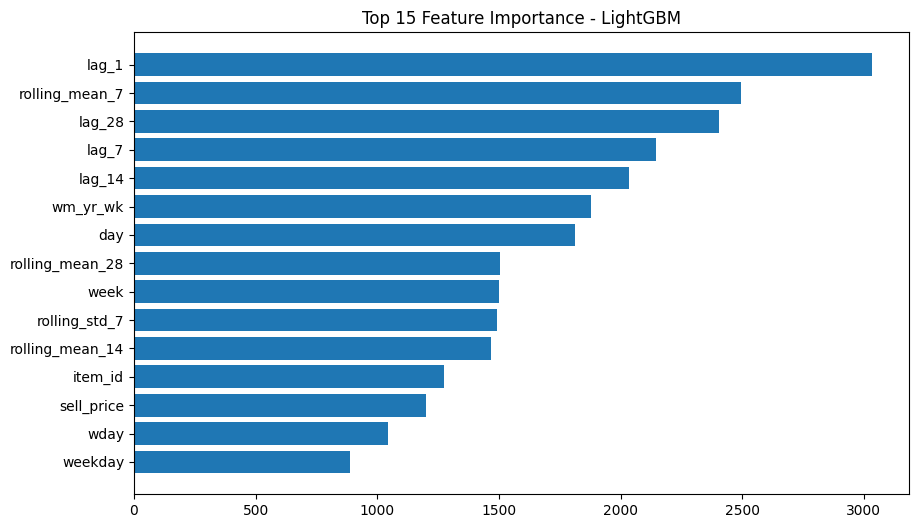

In [ ]:
top = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(top["Feature"], top["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance - LightGBM")

plt.show()

**Actual vs Predicted**

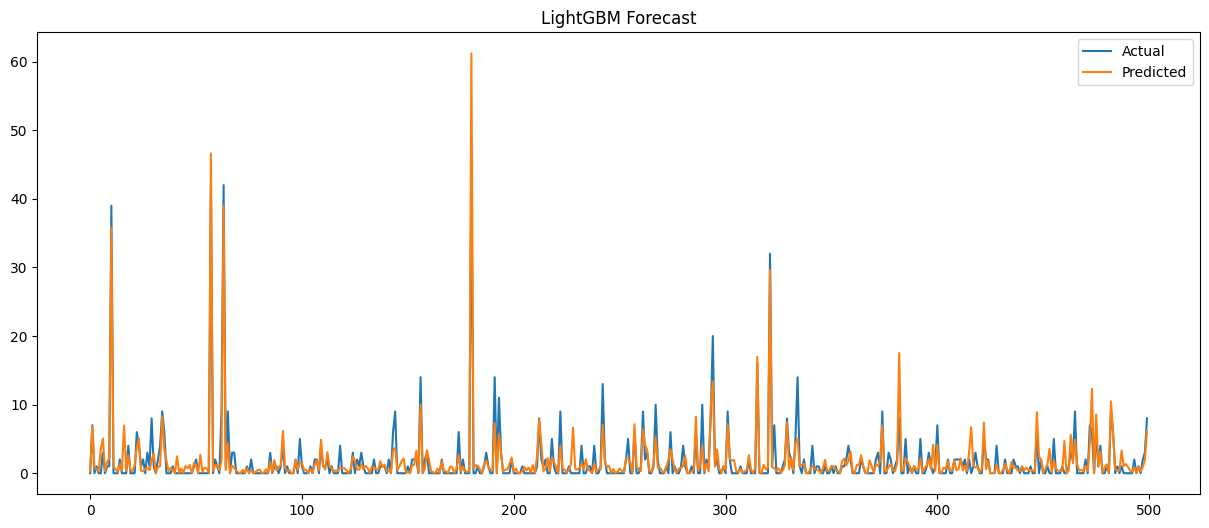

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(y_test.iloc[:500].values, label="Actual")

plt.plot(test_pred[:500], label="Predicted")

plt.legend()

plt.title("LightGBM Forecast")

plt.show()

**Save Model**

In [ ]:
MODEL_PATH="/content/drive/MyDrive/Enterprise_Retail_Intelligence/models/"

os.makedirs(MODEL_PATH, exist_ok=True)

joblib.dump(
    lgb_model,
    MODEL_PATH+"LightGBM.pkl"
)

['/content/drive/MyDrive/Enterprise_Retail_Intelligence/models/LightGBM.pkl']

**Save Predictions**

In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": test_pred
})

results.to_csv(
    RESULTS_PATH+"LightGBM_predictions.csv",
    index=False
)

print("LightGBM model saved successfully!")

LightGBM model saved successfully!


**Save Metrics**

In [ ]:
metrics_df = pd.DataFrame({
    "Model": ["LightGBM"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape],
    "R2": [r2]
})

metrics_df.to_csv(
    RESULTS_PATH + "LightGBM_metrics.csv",
    index=False
)

print("✅ LightGBM metrics saved successfully!")
metrics_df

✅ LightGBM metrics saved successfully!


,Model,MAE,RMSE,MAPE,R2
0,LightGBM,1.013185,2.024918,57.329589,0.67318


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/models/"

import joblib

joblib.dump(
    FEATURES,
    MODEL_PATH + "features.pkl"
)

print("✅ Features saved successfully!")

NameError: name 'FEATURES' is not defined